                                       🎥.MOVIE RECOMMENDATION SYSTEM

### 📌 Introduction_ 

✳️This project focuses on building a Movie Recommendation System that suggests movies to users based on their preferences. The system uses data preprocessing, feature extraction, and similarity techniques to recommend relevant movies.

✳️ In this project,a movie recommendation system is developed using the MovieLens dataset containing information about movies, genres, user             ratings, and timestamps. The system analyzes movie features and user behavior to generate personalized movie recommendations.

✳️ The project mainly focuses on Content-Based Filtering, where movies are recommended based on similarities in genres and movie attributes. Cosine     Similarity and Count Vectorization techniques are used to measure the similarity between movies. Additionally, exploratory data analysis (EDA) and     visualizations are performed to better understand rating patterns, popular genres, and user activity.

### Main Objectives Our Projects:

        ✅ To analyze movie and rating datasets
        
        ✅ To perform data preprocessing and visualization

        ✅ To build a movie recommendation model

        ✅ To recommend similar movies based on user input

        ✅ To provide personalized movie suggestions

        ✅ To understand recommendation system techniques used in real-world applications

### Python Libaries to use on based our project :
  📖Library	             ✅Purpose
  
  🔹pandas-->	          Data loading and manipulation
  
 🔹 numpy-->	              Numerical calculations
  
  🔹matplotlib-->      Basic plotting and charts
  
  🔹seaborn-->		          Advanced data visualization
  
  🔹CountVectorizer-->		  Convert text data into vectors
  
  🔹cosine_similarity -->	  Measure similarity between movies
  
  🔹WordCloud -->	         Generate movie title word clouds
  
 🔹 warnings	-->	          Hide unnecessary warnings

### Importing Libaries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

### 💠 Import Datasets

In [2]:
Movie_data=pd.read_csv('movies.csv')
Rating_Analysis=pd.read_csv('ratings.csv')

In [3]:
Movie_data.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [4]:
Rating_Analysis.head(10)

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
5,1,1088,4.0,1147868495
6,1,1175,3.5,1147868826
7,1,1217,3.5,1147878326
8,1,1237,5.0,1147868839
9,1,1250,4.0,1147868414


### ℹ️ Data Collection

In [5]:
Movie_data.shape

(62423, 3)

In [6]:
Rating_Analysis.shape

(25000095, 4)

In [7]:
Movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [8]:
Rating_Analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


In [9]:
Rating_Analysis.describe().T

,count,mean,std,min,25%,50%,75%,max
userId,25000095.0,8.118928e+04,4.679172e+04,1.0,4.051000e+04,8.091400e+04,1.215570e+05,1.625410e+05
movieId,25000095.0,2.138798e+04,3.919886e+04,1.0,1.196000e+03,2.947000e+03,8.623000e+03,2.091710e+05
rating,25000095.0,3.533854e+00,1.060744e+00,0.5,3.000000e+00,3.500000e+00,4.000000e+00,5.000000e+00
timestamp,25000095.0,1.215601e+09,2.268758e+08,789652009.0,1.011747e+09,1.198868e+09,1.447205e+09,1.574328e+09


### ♂️Data Processing

In [10]:
# Missing values in Movies Dataset
Movie_data.isnull().sum()


movieId    0
title      0
genres     0
dtype: int64

In [11]:
# Missing values in Ratings Dataset
Rating_Analysis.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [12]:
# Duplicate values in Movies Dataset
Movie_data.duplicated().sum()


np.int64(0)

In [13]:
# Duplicate values in Ratings Dataset
Rating_Analysis.duplicated().sum()

np.int64(0)

In [14]:
# Fill missing genres with empty string
Movie_data['genres'] =Movie_data['genres'].fillna('')
# Merge datasets
movies_recommendation_Systems= pd.merge(Rating_Analysis, Movie_data, on='movieId')

movies_recommendation_Systems.head(10)

,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance
5,1,1088,4.0,1147868495,Dirty Dancing (1987),Drama|Musical|Romance
6,1,1175,3.5,1147868826,Delicatessen (1991),Comedy|Drama|Romance
7,1,1217,3.5,1147878326,Ran (1985),Drama|War
8,1,1237,5.0,1147868839,"Seventh Seal, The (Sjunde inseglet, Det) (1957)",Drama
9,1,1250,4.0,1147868414,"Bridge on the River Kwai, The (1957)",Adventure|Drama|War


In [15]:
movies_recommendation_Systems.shape

(25000095, 6)

In [17]:
# identfiy
movies_recommendation_Systems.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')

### 📊 Exploratory Data Analysis (EDA)

 -> An EDA is used to understand the dataset through statistics and visualizations.
 
    Popular movies
    Rating patterns
    Genre distribution
    User activity
    Trends in the dataset
    
 * EDA is an important step before building the recommendation system

### 🎥 Top Rated Movies List


In [18]:
# Average rating of each movie
top_rated = movies_recommendation_Systems.groupby('title')['rating'].mean().sort_values(ascending=False)

# Convert into dataframe
top_rated = pd.DataFrame(top_rated)

# Display top 10 rated movies
top_rated.head(15) 

,rating
title,
Iran Is Not the Problem (2008),5.0
.hack Liminality In the Case of Yuki Aihara,5.0
$uperthief: Inside America's Biggest Bank Score (2012),5.0
.hack Liminality In the Case of Kyoko Tohno,5.0
...E fuori nevica! (2014),5.0
The Girl from Flanders (1956),5.0
'Master Harold' ... And the Boys (2010),5.0
Isabelle Dances Into the Spotlight (2014),5.0
"Love, Cheat & Steal (1993)",5.0


### ⭐ Most Popular Movies In List

In [19]:
# Count ratings for each movie
popular_movies = movies_recommendation_Systems.groupby('title')['rating'].count().sort_values(ascending=False)

# Convert into dataframe
popular_movies = pd.DataFrame(popular_movies)

# Display top 10 popular movies
popular_movies.head(15)

,rating
title,
Forrest Gump (1994),81491
"Shawshank Redemption, The (1994)",81482
Pulp Fiction (1994),79672
"Silence of the Lambs, The (1991)",74127
"Matrix, The (1999)",72674
Star Wars: Episode IV - A New Hope (1977),68717
Jurassic Park (1993),64144
Schindler's List (1993),60411
Braveheart (1995),59184


### 📈 Rating Distribution

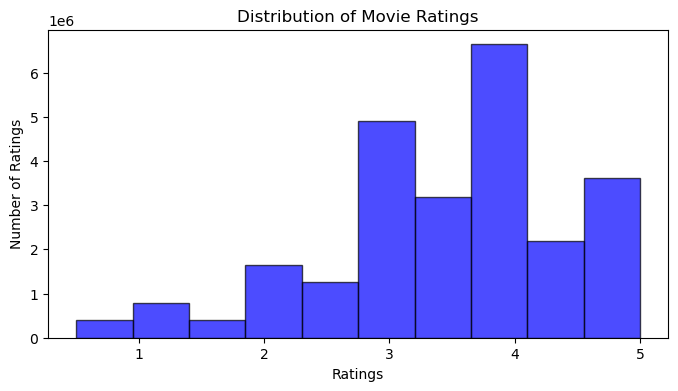

In [20]:
plt.figure(figsize=(8,4))

plt.hist(movies_recommendation_Systems['rating'],
    color='blue',
    edgecolor='black',
    alpha=0.7)

plt.xlabel("Ratings")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")
plt.show()

### 🎦Genre Analysis ###

In [21]:

genres = movies_recommendation_Systems['genres'].str.split('|').explode()

genre_count = genres.value_counts()

genre_count

genres
Drama                 10962833
Comedy                 8926230
Action                 7446918
Thriller               6763272
Adventure              5832424
Romance                4497291
Sci-Fi                 4325740
Crime                  4190259
Fantasy                2831585
Children               2124258
Mystery                2010995
Horror                 1892183
Animation              1630987
War                    1267346
IMAX                   1063279
Musical                 964252
Western                 483731
Documentary             322449
Film-Noir               247227
(no genres listed)       26627
Name: count, dtype: int64

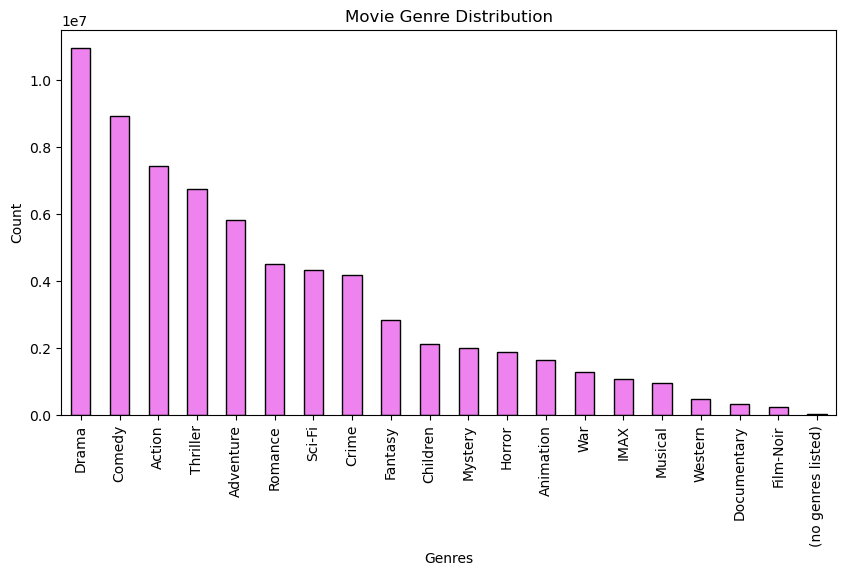

In [23]:
plt.figure(figsize=(10,5))
genre_count.plot(kind='bar',color='violet',edgecolor='black')

plt.xlabel("Genres")
plt.ylabel("Count")
plt.title("Movie Genre Distribution")
plt.show()

### Most Active  Users To Watch

In [24]:
# Extract year
movies_recommendation_Systems['year'] =movies_recommendation_Systems['title'].str.extract(r'\((\d{4})\)')

# Display first rows
movies_recommendation_Systems.head(10)

,userId,movieId,rating,timestamp,title,genres,year
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1994
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama,1994
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama,1993
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War,1995
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance,1952
5,1,1088,4.0,1147868495,Dirty Dancing (1987),Drama|Musical|Romance,1987
6,1,1175,3.5,1147868826,Delicatessen (1991),Comedy|Drama|Romance,1991
7,1,1217,3.5,1147878326,Ran (1985),Drama|War,1985
8,1,1237,5.0,1147868839,"Seventh Seal, The (Sjunde inseglet, Det) (1957)",Drama,1957
9,1,1250,4.0,1147868414,"Bridge on the River Kwai, The (1957)",Adventure|Drama|War,1957


### 📉 Movies Released Trend

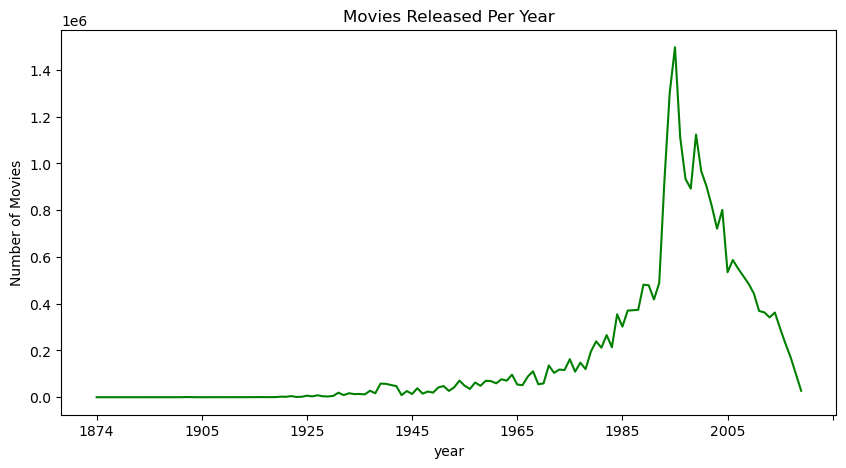

In [26]:
movies_per_year = movies_recommendation_Systems['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

movies_per_year.plot(color='green')

plt.xlabel("year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")

plt.show()

### 🎯Bulding Recommendation Systems

In [27]:
movies_Recommendations_data =movies_recommendation_Systems [['movieId', 'title', 'genres']]

movies_Recommendations_data.head(10)

,movieId,title,genres
0,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,306,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,307,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,665,Underground (1995),Comedy|Drama|War
4,899,Singin' in the Rain (1952),Comedy|Musical|Romance
5,1088,Dirty Dancing (1987),Drama|Musical|Romance
6,1175,Delicatessen (1991),Comedy|Drama|Romance
7,1217,Ran (1985),Drama|War
8,1237,"Seventh Seal, The (Sjunde inseglet, Det) (1957)",Drama
9,1250,"Bridge on the River Kwai, The (1957)",Adventure|Drama|War


In [28]:
movies_Recommendations_data.shape

(25000095, 3)

In [34]:
movies_Recommendations_data['genres'] = movies_Recommendations_data['genres'].fillna('')
# Initialize CountVectorizer
cv = CountVectorizer(tokenizer=lambda x: x.split('|'))

# Convert genres into matrix
count_matrix = cv.fit_transform(movies_Recommendations_data['genres'])

print(count_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 67809886 stored elements and shape (25000095, 20)>
  Coords	Values
  (0, 5)	1
  (0, 6)	1
  (0, 8)	1
  (0, 17)	1
  (1, 8)	1
  (2, 8)	1
  (3, 5)	1
  (3, 8)	1
  (3, 18)	1
  (4, 5)	1
  (4, 13)	1
  (4, 15)	1
  (5, 8)	1
  (5, 13)	1
  (5, 15)	1
  (6, 5)	1
  (6, 8)	1
  (6, 15)	1
  (7, 8)	1
  (7, 18)	1
  (8, 8)	1
  (9, 8)	1
  (9, 18)	1
  (9, 2)	1
  (10, 6)	1
  :	:
  (25000086, 15)	1
  (25000086, 2)	1
  (25000086, 9)	1
  (25000086, 3)	1
  (25000087, 6)	1
  (25000087, 1)	1
  (25000087, 12)	1
  (25000088, 2)	1
  (25000088, 9)	1
  (25000088, 4)	1
  (25000089, 5)	1
  (25000089, 4)	1
  (25000089, 3)	1
  (25000090, 8)	1
  (25000090, 4)	1
  (25000090, 3)	1
  (25000091, 5)	1
  (25000091, 3)	1
  (25000092, 5)	1
  (25000092, 4)	1
  (25000093, 6)	1
  (25000093, 8)	1
  (25000093, 1)	1
  (25000093, 12)	1
  (25000094, 8)	1


In [35]:
count_matrix.shape

(25000095, 20)

In [36]:
tfidf = TfidfVectorizer(token_pattern=r'[^|]+')

tfidf_matrix = tfidf.fit_transform(movies_recommendation_Systems['genres'])


In [37]:
model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)
model.fit(tfidf_matrix)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [40]:
def recommend(movie_name):

    movie_name = movie_name.lower()

    # Find movie index
    idx = movies_recommendation_Systems[
        movies_recommendation_Systems['title'].str.lower() == movie_name
    ].index

    if len(idx) == 0:
        print("Movie not found!")
        return

    idx = idx[0]

    # Find nearest neighbors
    distances, indices = model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=11
    )

    print(f"\n🎬 Recommended Movies for '{movies_recommendation_Systems.iloc[idx]['title']}'\n")

    for i in range(1, len(indices[0])):
        movie_idx = indices[0][i]
        print(movies_recommendation_Systems.iloc[movie_idx]['title'])

In [41]:
recommend("Toy Story (1995)")


🎬 Recommended Movies for 'Toy Story (1995)'

Monsters, Inc. (2001)
Monsters, Inc. (2001)
Toy Story 2 (1999)
Monsters, Inc. (2001)
Monsters, Inc. (2001)
Toy Story (1995)
Monsters, Inc. (2001)
Monsters, Inc. (2001)
Monsters, Inc. (2001)
Monsters, Inc. (2001)


In [42]:
recommend("Jumanji (1995)")


🎬 Recommended Movies for 'Jumanji (1995)'

Chronicles of Narnia: The Lion, the Witch and the Wardrobe, The (2005)
Pan (2015)
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)
NeverEnding Story, The (1984)
Chronicles of Narnia: Prince Caspian, The (2008)
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)
Bridge to Terabithia (2007)
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)
Chronicles of Narnia: The Lion, the Witch and the Wardrobe, The (2005)


In [43]:
recommend('Underground (1995)')


🎬 Recommended Movies for 'Underground (1995)'

Good Morning, Vietnam (1987)
M*A*S*H (a.k.a. MASH) (1970)
M*A*S*H (a.k.a. MASH) (1970)
M*A*S*H (a.k.a. MASH) (1970)
M*A*S*H (a.k.a. MASH) (1970)
Good Morning, Vietnam (1987)
M*A*S*H (a.k.a. MASH) (1970)
Good Morning, Vietnam (1987)
Good Morning, Vietnam (1987)
To Be or Not to Be (1942)


In [44]:
recommend("Dargaon")

Movie not found!


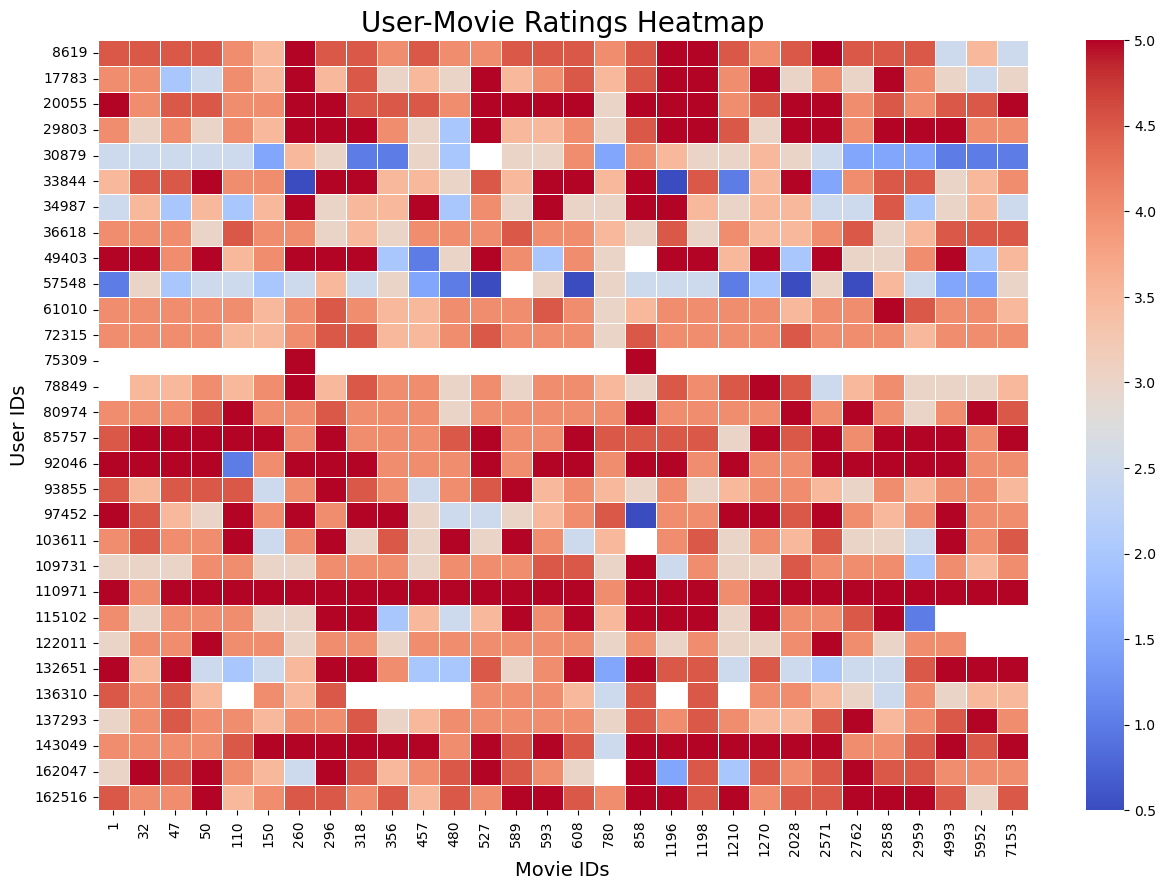

In [46]:
# USER-MOVIE RATINGS HEATMAP
# ==================================

# Reload data after kernel restart
Rating_Analysis = pd.read_csv("ratings.csv", dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

# Filter to top 30 users and top 30 movies BEFORE pivot
Top_movies = Rating_Analysis['movieId'].value_counts().head(30).index
Top_users  = Rating_Analysis['userId'].value_counts().head(30).index

filtered = Rating_Analysis[
    Rating_Analysis['movieId'].isin(Top_movies) &
    Rating_Analysis['userId'].isin(Top_users)
]

# Create User-Movie Matrix
movie_matrix = filtered.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Select smaller portion for visualization
heatmap_data = movie_matrix.iloc[:30, :30]

# Create Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

# Titles and Labels
plt.title("User-Movie Ratings Heatmap", fontsize=20)
plt.xlabel("Movie IDs", fontsize=14)
plt.ylabel("User IDs", fontsize=14)

plt.show()